In [1]:
import awkward as ak
import os

data_base_dir = "/srv/beegfs/scratch/groups/rodem/lumea/datasets/JetClass/Pythia/cont_alfa_tokenized_allfeat/2026-08-04_14-03-40_gpu024_EquestrianSymbol/train_100M"

fp = (
    os.path.join(data_base_dir, "ZJetsToNuNu_000_tokenized.parquet")
)

In [2]:
meta = ak.metadata_from_parquet(fp)
form = meta["form"]
print("top-level fields:", form.fields)

top-level fields: ['part_token_id', 'particle_features_tokenized', 'particle_features', 'jet_features']


In [3]:
arr = ak.from_parquet(fp, row_groups={0})

In [4]:
arr.part_token_id.fields

['part_token_id']

In [5]:
arr.part_token_id

<Array [{part_token_id: [0, ...]}, ..., {...}] type='100000 * {part_token_i...'>

In [6]:
arr.particle_features_tokenized.fields

['part_pt',
 'part_etarel',
 'part_phirel',
 'part_mass',
 'part_charge',
 'part_isChargedHadron',
 'part_isNeutralHadron',
 'part_isPhoton',
 'part_isElectron',
 'part_isMuon',
 'part_d0val',
 'part_dzval',
 'part_d0err',
 'part_dzerr']

In [7]:
arr.particle_features_tokenized

<Array [{part_pt: [...], ...}, ..., {...}] type='100000 * {part_pt: var * f...'>

In [8]:
arr.particle_features.fields

['part_px',
 'part_py',
 'part_pz',
 'part_energy',
 'part_pt',
 'part_eta',
 'part_phi',
 'part_mass',
 'part_ptrel',
 'part_erel',
 'part_etarel',
 'part_phirel',
 'part_deltaR',
 'part_deta',
 'part_dphi',
 'part_d0val',
 'part_d0err',
 'part_dzval',
 'part_dzerr',
 'part_charge',
 'part_isChargedHadron',
 'part_isNeutralHadron',
 'part_isPhoton',
 'part_isElectron',
 'part_isMuon']

In [9]:
arr.particle_features

<Array [{part_px: [...], ...}, ..., {...}] type='100000 * {part_px: var * f...'>

In [10]:
arr.jet_features.fields

['jet_pt',
 'jet_eta',
 'jet_phi',
 'jet_energy',
 'jet_nparticles',
 'jet_mass_from_p4s',
 'jet_pt_from_p4s',
 'jet_eta_from_p4s',
 'jet_phi_from_p4s',
 'jet_sdmass',
 'jet_tau1',
 'jet_tau2',
 'jet_tau3',
 'jet_tau4']

In [11]:
arr.jet_features

<Array [{jet_pt: 567, jet_eta: ..., ...}, ...] type='100000 * {jet_pt: floa...'>

In [12]:
arr.particle_features_tokenized.part_charge

<Array [[0.999, -0.00217, ..., 0.999, -1], ...] type='100000 * var * float32'>

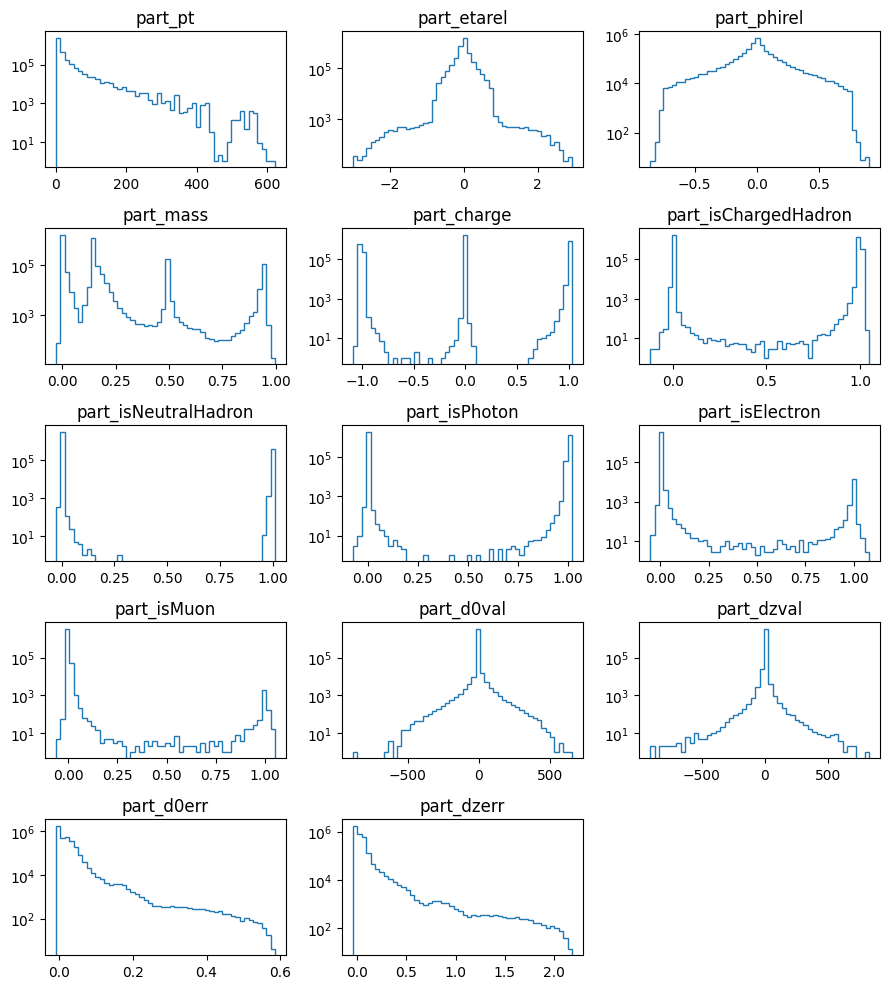

In [13]:
import matplotlib.pyplot as plt

fields = arr.particle_features_tokenized.fields
n_cols = 3
n_rows = -(-len(fields) // n_cols)  # ceil division

fig, axes = plt.subplots(n_rows, n_cols, figsize=(3 * n_cols, 2 * n_rows))
axes = axes.flatten()

for ax, field in zip(axes, fields):
    values = ak.flatten(arr.particle_features_tokenized[field], axis=None)
    values = ak.to_numpy(values)
    ax.hist(values, bins=50, histtype="step")
    ax.set_title(field)
    ax.set_yscale("log")

for ax in axes[len(fields):]:
    ax.axis("off")

fig.tight_layout()
plt.show()


In [18]:
import heputl.plotting.oneD as heplt

In [32]:
fp2 = "HToCC_000_tokenized.parquet"

In [34]:
arr2 = ak.from_parquet(os.path.join(data_base_dir, fp2))

In [ ]:
labels = ['ZJetsnunu','HToCC']
dats = [arr.particle_features_tokenized.part_pt, arr2.particle_features_tokenized.part_pt]
heplt.plot_feature_hist_for_n_samples(
    data=dats,
    sample_names=labels,
    feature_name='part_pt',
    bins=70,
    logy=True,
    density=True,
    title='part_pt distribution for ZJetsnunu and HToCC',
    show_plt=True
)

TypeError: plot_feature_hist_for_n_samples() got an unexpected keyword argument 'dats'

In [31]:
!ls $data_base_dir | grep HToCC

HToCC_000_tokenized.parquet
HToCC_001_tokenized.parquet
HToCC_002_tokenized.parquet
HToCC_003_tokenized.parquet
HToCC_004_tokenized.parquet
HToCC_005_tokenized.parquet
HToCC_006_tokenized.parquet
HToCC_007_tokenized.parquet
HToCC_008_tokenized.parquet
HToCC_009_tokenized.parquet
HToCC_010_tokenized.parquet
HToCC_011_tokenized.parquet
HToCC_012_tokenized.parquet
HToCC_013_tokenized.parquet
HToCC_014_tokenized.parquet
HToCC_015_tokenized.parquet
HToCC_016_tokenized.parquet
HToCC_017_tokenized.parquet
HToCC_018_tokenized.parquet
HToCC_019_tokenized.parquet
HToCC_020_tokenized.parquet
HToCC_021_tokenized.parquet
HToCC_022_tokenized.parquet
HToCC_023_tokenized.parquet
HToCC_024_tokenized.parquet
HToCC_025_tokenized.parquet
HToCC_026_tokenized.parquet
HToCC_027_tokenized.parquet
HToCC_028_tokenized.parquet
HToCC_029_tokenized.parquet
HToCC_030_tokenized.parquet
HToCC_031_tokenized.parquet
HToCC_032_tokenized.parquet
HToCC_033_tokenized.parquet
HToCC_034_tokenized.parquet
HToCC_035_tokenized.